# blrfit quickstart

Fit one spectrum, read its measurements, classes and flags, look at the fit, collect several fits into one table, and add Monte Carlo errors. Run it from the `examples/` directory: the spectra are in `data/`.

In [ ]:
import blrfit

print(blrfit.__version__)

sp = blrfit.read_spectrum("data/spec-0651-52141-0072.fits", survey="sdss", mask_policy="conservative")
res = blrfit.fit_spectrum(sp["wave"], sp["flux"], sp["ivar"], z=0.2288, ebv=0.0)

0.3.0.dev0


## Measurements, classes and flags

`res["meas"][line]` holds the measurements of each line and `res["cls"][line]` its class, the reasons for it and the flags. Velocities ending in `_sys` are relative to the narrow lines; `c50_sys` is the offset Δv of the half-maximum bisector.

In [ ]:
for line in ("Halpha", "Hbeta"):
    m, c = res["meas"][line], res["cls"][line]
    print(f"{line}: class {c['label']} ({blrfit.LABEL_TEXT[c['label']]}), dv = {m['c50_sys']:+.0f} km/s, "
          f"FWHM = {m['fwhm']:.0f} km/s, flags: {', '.join(c['flags']) or 'none'}")
    print("    " + "; ".join(c["reasons"]))

for flag in sorted({f for c in res["cls"].values() for f in c["flags"]}):
    print(f"{flag}: {blrfit.FLAG_TEXT[flag]}")

Halpha: class C (asymmetric), dv = -1566 km/s, FWHM = 3678 km/s, flags: pl_unphysical
    asymmetric: tilt 0.50 FWHM, A.I. 0.42, |peak-cen| 0.43 FWHM, offset -1566
Hbeta: class C (asymmetric), dv = -1273 km/s, FWHM = 3619 km/s, flags: pl_unphysical
    asymmetric: tilt 0.57 FWHM, A.I. 0.50, |peak-cen| 0.89 FWHM, offset -1273
pl_unphysical: power-law slope bluer than an accretion disc (alpha < -2.5)


## The fit

The diagnostic figure: the spectrum with the continuum model, and for each line complex the continuum-subtracted data, the narrow and broad components and the residuals.

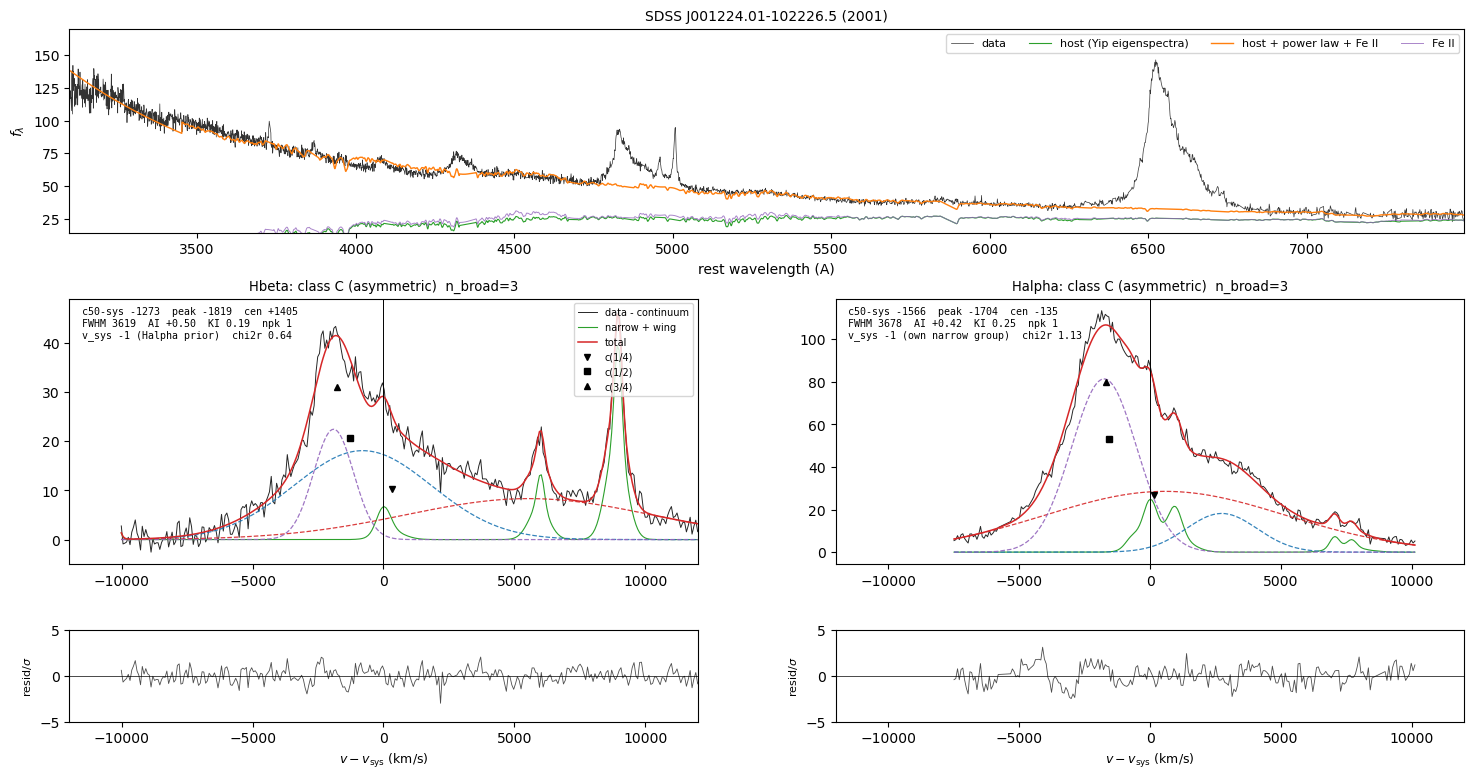

In [ ]:
fig = blrfit.plot_fit(res, title="SDSS J001224.01-102226.5 (2001)")

## One row per spectrum

`summary_row` flattens a fit into one row, and `summary_table` collects rows into an astropy table with units. The command line does the same for many spectra: `blrfit fit data/spec-*.fits --survey sdss` writes `blrfit_summary.fits`.

In [ ]:
from blrfit.batch import summary_table

rows = []
for path in ("data/spec-0651-52141-0072.fits", "data/spec-7169-56628-0344.fits"):
    s = blrfit.read_spectrum(path, survey="sdss", mask_policy="conservative")
    r = blrfit.fit_spectrum(s["wave"], s["flux"], s["ivar"], z=0.2288, ebv=0.0)
    rows.append(dict(spectrum=path, **blrfit.summary_row(r)))
table = summary_table(rows)
table["spectrum", "HB_class", "HB_c50_sys", "HB_fwhm", "HA_class", "HA_c50_sys", "HA_flags"]

spectrum,HB_class,HB_c50_sys,HB_fwhm,HA_class,HA_c50_sys,HA_flags
,,km / s,km / s,,km / s,
str30,str1,float64,float64,str1,float64,str13
data/spec-0651-52141-0072.fits,C,-1272.7928897620461,3619.083025255885,C,-1566.0479720570029,pl_unphysical
data/spec-7169-56628-0344.fits,C,-1642.7526235987536,3007.119247701121,C,-1880.7711274153762,


## Monte Carlo errors

Errors come from refits of the spectrum perturbed with its pixel noise, with the host and the number of broad components held fixed. At least 25 draws are needed; we use 200. `jobs` spreads the draws over processes and does not change the result. When the draws split between separate solutions, the line is flagged and its errors are withheld (`nan`).

In [ ]:
res_mc = blrfit.fit_spectrum(sp["wave"], sp["flux"], sp["ivar"], z=0.2288, ebv=0.0, nmc=30, jobs=4)
for line in ("Halpha", "Hbeta"):
    m, e = res_mc["meas"][line], res_mc["err"][line]
    print(f"{line}: dv = {m['c50_sys']:+.0f} +/- {e['c50_sys']:.0f} km/s, flags: {res_mc['cls'][line]['flags']}")

Halpha: dv = -1566 +/- 163 km/s, flags: ['pl_unphysical']
Hbeta: dv = -1273 +/- 142 km/s, flags: ['pl_unphysical']


The model, the outputs and the validation are described in [docs](../docs/method.md).